<a href="https://colab.research.google.com/github/shahbaz11-arch/NNDDE/blob/main/Problem_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Discovered Network Weights ---
w0: 1.266066
w1: -1.130318
w2: 0.271495
w3: -0.044337

--- Solution Evaluation (11 Test Points) ---
x     | y_approx     | y_exact (e^-x)  | Relative Error 
-------------------------------------------------------
0.000 | 1.000000     | 1.000000        | 0.0000e+00     
0.100 | 0.904837     | 0.904837        | 3.0675e-15     
0.200 | 0.818731     | 0.818731        | 3.1189e-15     
0.300 | 0.740818     | 0.740818        | 3.1472e-15     
0.400 | 0.670320     | 0.670320        | 2.8156e-15     
0.500 | 0.606531     | 0.606531        | 2.9287e-15     
0.600 | 0.548812     | 0.548812        | 2.6298e-15     
0.700 | 0.496585     | 0.496585        | 1.9004e-15     
0.800 | 0.449329     | 0.449329        | 1.2354e-16     
0.900 | 0.406570     | 0.406570        | 5.4614e-16     
1.000 | 0.367879     | 0.367879        | 8.7519e-15     


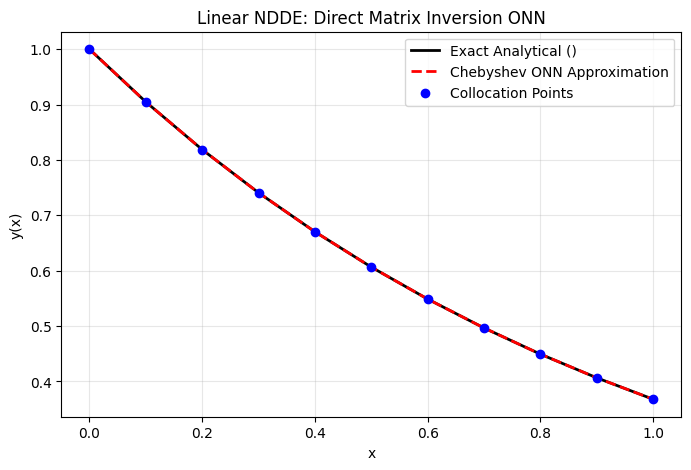

In [11]:
#Problem-3 (Verified)
import torch
import matplotlib.pyplot as plt

# ==========================================
# 1. Chebyshev Basis Implementation
# ==========================================
def get_chebyshev_basis(x, n_polys):
    """
    Generates Chebyshev polynomials T_n(x) and T'_n(x)
    using recurrence relations for n = 0 to n_polys-1.
    """
    if x.dim() == 0:
        x = x.unsqueeze(0)

    num_points = len(x)
    T = torch.zeros(num_points, n_polys, dtype=torch.float64)
    T_d = torch.zeros(num_points, n_polys, dtype=torch.float64)

    # Base Case: n=0 -> T_0 = 1, T'_0 = 0
    T[:, 0] = 1.0

    if n_polys > 1:
        # Base Case: n=1 -> T_1 = x, T'_1 = 1
        T[:, 1] = x
        T_d[:, 1] = 1.0

    # Recurrence Loop for n >= 2
    for n in range(2, n_polys):
        T[:, n] = 2 * x * T[:, n-1] - T[:, n-2]
        T_d[:, n] = 2 * T[:, n-1] + 2 * x * T_d[:, n-1] - T_d[:, n-2]

    return T, T_d

# ==========================================
# 2. Problem Setup (Linear NDDE)
# ==========================================
# Equation: y'(x) + e^x y'(x - sin(x^2)) + cos(x)y(x - sin(x)) = -e^{-x} - e^{sin(x^2)} + cos(x)e^{sin(x) - x}
# IC: y(0) = e^0 = 1

N_POLYS = 12
points_colloc = torch.linspace(0,1,11,  dtype=torch.float64)

# Initialize Square System (4 equations, 4 unknowns)
A = torch.zeros(12, N_POLYS, dtype=torch.float64)
b = torch.zeros(12, 1, dtype=torch.float64)

# --- Row 0: Initial Condition y(0) = 1 ---
T_0, _ = get_chebyshev_basis(torch.tensor([0.0], dtype=torch.float64), N_POLYS)
A[0, :] = T_0
b[0, 0] = 1.0

# --- Rows 1-3: ODE Constraints at Collocation Points ---
for i, x_val in enumerate(points_colloc):
    x = torch.tensor([x_val], dtype=torch.float64)

    # 1. Compute delayed arguments
    # Note: For x in {0, 0.5, 1}, these delays are all >= 0, so they fall within our approximation domain.
    delay_1 = x - torch.sin(x**2)
    delay_2 = x - torch.sin(x)

    # 2. Evaluate basis at current and delayed arguments
    T_x, Td_x = get_chebyshev_basis(x, N_POLYS)
    _, Td_delay1 = get_chebyshev_basis(delay_1, N_POLYS)
    T_delay2, _ = get_chebyshev_basis(delay_2, N_POLYS)

    # 3. Construct LHS (Coefficients for w_n)
    # y'(x) + e^x y'(x - sin(x^2)) + cos(x)y(x - sin(x))
    exp_x = torch.exp(x)
    cos_x = torch.cos(x)

    coeffs = Td_x + exp_x * Td_delay1 + cos_x * T_delay2
    A[i+1, :] = coeffs

    # 4. Construct RHS
    # f(x) = -e^{-x} - e^{sin(x^2)} + cos(x)e^{sin(x) - x}
    rhs = -torch.exp(-x) - torch.exp(torch.sin(x**2)) + cos_x * torch.exp(torch.sin(x) - x)
    b[i+1, 0] = rhs

# ==========================================
# 3. Solve for Weights (Direct Matrix Inversion)
# ==========================================
# Since the NDDE is linear, we find exact analytical weights using torch.linalg.solve
weights = torch.linalg.solve(A, b)

print("--- Discovered Network Weights ---")
print(f"w0: {weights[0].item():.6f}")
print(f"w1: {weights[1].item():.6f}")
print(f"w2: {weights[2].item():.6f}")
print(f"w3: {weights[3].item():.6f}")

# ==========================================
# 4. Evaluate Solution and Relative Error
# ==========================================
print("\n--- Solution Evaluation (11 Test Points) ---")
print(f"{'x':<5} | {'y_approx':<12} | {'y_exact (e^-x)':<15} | {'Relative Error':<15}")
print("-" * 55)

x_eval = torch.linspace(0, 1, 11, dtype=torch.float64)
T_eval, _ = get_chebyshev_basis(x_eval, N_POLYS)

# Calculate approximate and exact solutions
y_approx = (T_eval @ weights).flatten()
y_exact = torch.exp(-x_eval)

# Compute relative error
rel_errors = torch.abs(y_approx - y_exact) / torch.abs(y_exact)

for i in range(len(x_eval)):
    x_val = x_eval[i].item()
    approx_val = y_approx[i].item()
    exact_val = y_exact[i].item()
    error_val = rel_errors[i].item()

    print(f"{x_val:<5.3f} | {approx_val:<12.6f} | {exact_val:<15.6f} | {error_val:<15.4e}")

# Visualization
plt.figure(figsize=(8, 5))
plt.plot(x_eval.numpy(), y_exact.numpy(), 'k-', linewidth=2, label='Exact Analytical ()')
plt.plot(x_eval.numpy(), y_approx.numpy(), 'r--', linewidth=2, label='Chebyshev ONN Approximation')
plt.scatter(points_colloc.numpy(), (get_chebyshev_basis(points_colloc, N_POLYS)[0] @ weights).flatten().numpy(),
            color='blue', zorder=5, label='Collocation Points')
plt.title("Linear NDDE: Direct Matrix Inversion ONN")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


--- Discovered Network Weights ---
w0: 1.175201
w1: -1.103638
w2: 0.357814

--- Solution Evaluation (11 Test Points) ---
x     | y_approx     | y_exact (e^-x)  | Relative Error 
-------------------------------------------------------
0.000 | 1.000000     | 1.000000        | 2.2204e-16     
0.100 | 0.904837     | 0.904837        | 3.4356e-15     
0.200 | 0.818731     | 0.818731        | 3.3901e-15     
0.300 | 0.740818     | 0.740818        | 3.8965e-15     
0.400 | 0.670320     | 0.670320        | 3.4781e-15     
0.500 | 0.606531     | 0.606531        | 2.9287e-15     
0.600 | 0.548812     | 0.548812        | 3.0344e-15     
0.700 | 0.496585     | 0.496585        | 2.2357e-15     
0.800 | 0.449329     | 0.449329        | 4.9417e-16     
0.900 | 0.406570     | 0.406570        | 1.3654e-15     
1.000 | 0.367879     | 0.367879        | 7.2430e-15     


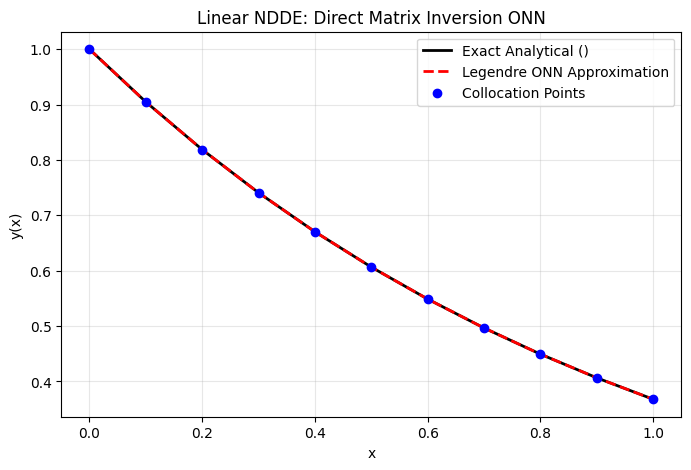

In [20]:
#Problem-3 (Legendre)(Verified)
import torch
import matplotlib.pyplot as plt

# ==========================================
# 1. Legendre Basis Implementation
# ==========================================
def get_Legendre_basis(x, n_polys):
    """
    Generates Legendre polynomials T_n(x) and T'_n(x)
    using recurrence relations for n = 0 to n_polys-1.
    """
    if x.dim() == 0:
        x = x.unsqueeze(0)

    num_points = len(x)
    T = torch.zeros(num_points, n_polys, dtype=torch.float64)
    T_d = torch.zeros(num_points, n_polys, dtype=torch.float64)

    # Base Case: n=0 -> T_0 = 1, T'_0 = 0
    T[:, 0] = 1.0

    if n_polys > 1:
        # Base Case: n=1 -> T_1 = x, T'_1 = 1
        T[:, 1] = x
        T_d[:, 1] = 1.0

    # Recurrence Loop for n >= 2

    for n in range(2, n_polys):
      T[:, n] = ((2.0 * n - 1.0) * x * T[:, n-1] - (n - 1.0) * T[:, n-2]) / n
      T_d[:, n] = ((2.0 * n - 1.0) * (T[:, n-1] + x * T_d[:, n-1]) - (n - 1.0) * T_d[:, n-2]) / n
    return T, T_d



# ==========================================
# 2. Problem Setup (Linear NDDE)
# ==========================================
# Equation: y'(x) + e^x y'(x - sin(x^2)) + cos(x)y(x - sin(x)) = -e^{-x} - e^{sin(x^2)} + cos(x)e^{sin(x) - x}
# IC: y(0) = e^0 = 1

N_POLYS = 12
points_colloc = torch.linspace(0,1,11,  dtype=torch.float64)

# Initialize Square System (4 equations, 4 unknowns)
A = torch.zeros(12, N_POLYS, dtype=torch.float64)
b = torch.zeros(12, 1, dtype=torch.float64)

# --- Row 0: Initial Condition y(0) = 1 ---
T_0, _ = get_Legendre_basis(torch.tensor([0.0], dtype=torch.float64), N_POLYS)
A[0, :] = T_0
b[0, 0] = 1.0

# --- Rows 1-3: ODE Constraints at Collocation Points ---
for i, x_val in enumerate(points_colloc):
    x = torch.tensor([x_val], dtype=torch.float64)

    # 1. Compute delayed arguments
    # Note: For x in {0, 0.5, 1}, these delays are all >= 0, so they fall within our approximation domain.
    delay_1 = x - torch.sin(x**2)
    delay_2 = x - torch.sin(x)

    # 2. Evaluate basis at current and delayed arguments
    T_x, Td_x = get_Legendre_basis(x, N_POLYS)
    _, Td_delay1 = get_Legendre_basis(delay_1, N_POLYS)
    T_delay2, _ = get_Legendre_basis(delay_2, N_POLYS)

    # 3. Construct LHS (Coefficients for w_n)
    # y'(x) + e^x y'(x - sin(x^2)) + cos(x)y(x - sin(x))
    exp_x = torch.exp(x)
    cos_x = torch.cos(x)

    coeffs = Td_x + exp_x * Td_delay1 + cos_x * T_delay2
    A[i+1, :] = coeffs

    # 4. Construct RHS
    # f(x) = -e^{-x} - e^{sin(x^2)} + cos(x)e^{sin(x) - x}
    rhs = -torch.exp(-x) - torch.exp(torch.sin(x**2)) + cos_x * torch.exp(torch.sin(x) - x)
    b[i+1, 0] = rhs

# ==========================================
# 3. Solve for Weights (Direct Matrix Inversion)
# ==========================================
# Since the NDDE is linear, we find exact analytical weights using torch.linalg.solve

weights = torch.linalg.solve(A, b)

print("--- Discovered Network Weights ---")
print(f"w0: {weights[0].item():.6f}")
print(f"w1: {weights[1].item():.6f}")
print(f"w2: {weights[2].item():.6f}")
#print(f"w3: {weights[3].item():.6f}")

# ==========================================
# 4. Evaluate Solution and Relative Error
# ==========================================
print("\n--- Solution Evaluation (11 Test Points) ---")
print(f"{'x':<5} | {'y_approx':<12} | {'y_exact (e^-x)':<15} | {'Relative Error':<15}")
print("-" * 55)

x_eval = torch.linspace(0, 1, 11, dtype=torch.float64)
T_eval, _ = get_Legendre_basis(x_eval, N_POLYS)

# Calculate approximate and exact solutions
y_approx = (T_eval @ weights).flatten()
y_exact = torch.exp(-x_eval)

# Compute relative error
rel_errors = torch.abs(y_approx - y_exact) / torch.abs(y_exact)

for i in range(len(x_eval)):
    x_val = x_eval[i].item()
    approx_val = y_approx[i].item()
    exact_val = y_exact[i].item()
    error_val = rel_errors[i].item()

    print(f"{x_val:<5.3f} | {approx_val:<12.6f} | {exact_val:<15.6f} | {error_val:<15.4e}")

# Visualization
plt.figure(figsize=(8, 5))
plt.plot(x_eval.numpy(), y_exact.numpy(), 'k-', linewidth=2, label='Exact Analytical ()')
plt.plot(x_eval.numpy(), y_approx.numpy(), 'r--', linewidth=2, label='Legendre ONN Approximation')
plt.scatter(points_colloc.numpy(), (get_Legendre_basis(points_colloc, N_POLYS)[0] @ weights).flatten().numpy(),
            color='blue', zorder=5, label='Collocation Points')
plt.title("Linear NDDE: Direct Matrix Inversion ONN")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


--- Discovered Probabilistic Hermite Weights ---
w0: 1.648673
w1: -1.648564
w2: 0.824097

--- Solution Evaluation (11 Test Points) ---
x     | y_approx     | y_exact (e^-x)  | Relative Error 
-------------------------------------------------------
0.000 | 1.000000     | 1.000000        | 2.2204e-16     
0.100 | 0.904837     | 0.904837        | 2.3313e-15     
0.200 | 0.818731     | 0.818731        | 2.1696e-15     
0.300 | 0.740818     | 0.740818        | 2.2480e-15     
0.400 | 0.670320     | 0.670320        | 2.4844e-15     
0.500 | 0.606531     | 0.606531        | 2.3796e-15     
0.600 | 0.548812     | 0.548812        | 2.2253e-15     
0.700 | 0.496585     | 0.496585        | 2.0121e-15     
0.800 | 0.449329     | 0.449329        | 1.2354e-16     
0.900 | 0.406570     | 0.406570        | 2.7307e-16     
1.000 | 0.367879     | 0.367879        | 9.3555e-15     


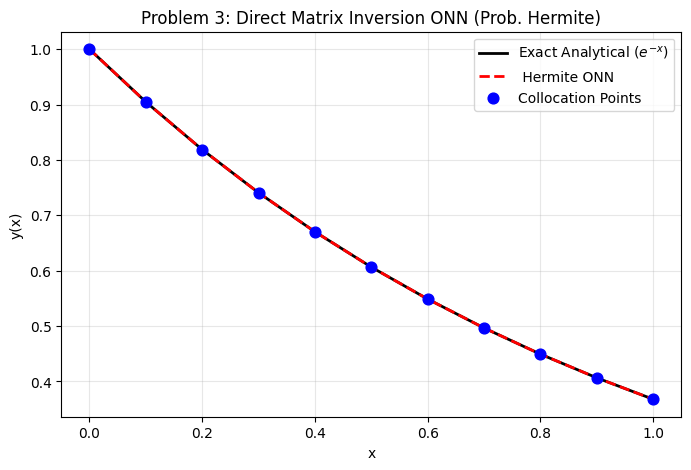

In [36]:
#Problem--3 (Verified)
import torch
import matplotlib.pyplot as plt

# ==========================================
# 1.  Hermite Basis Implementation
# ==========================================
def get_prob_hermite_basis(x, n_polys):
    """
    Generates Probabilistic Hermite polynomials He_n(x) and their derivatives He'_n(x)
    using standard recurrence relations for n = 0 to n_polys-1.
    """
    if x.dim() == 0:
        x = x.unsqueeze(0)

    num_points = len(x)
    He = torch.zeros(num_points, n_polys, dtype=torch.float64)
    He_d = torch.zeros(num_points, n_polys, dtype=torch.float64)

    # Base Case: n=0 -> He_0 = 1, He'_0 = 0
    He[:, 0] = 1.0

    if n_polys > 1:
        # Base Case: n=1 -> He_1 = x, He'_1 = 1
        He[:, 1] = x
        He_d[:, 1] = 1.0

    # Recurrence Loop for n >= 2
    for n in range(2, n_polys):
        He[:, n] = x * He[:, n-1] - (n - 1.0) * He[:, n-2]
        He_d[:, n] = float(n) * He[:, n-1]

    return He, He_d

# ==========================================
# 2. Problem Setup (Problem 3 Linear NDDE)
# ==========================================
N_POLYS = 12
points_colloc = torch.linspace(0,1,11,  dtype=torch.float64)

# Initialize Square System (3 equations, 3 unknowns)
A = torch.zeros(12, N_POLYS, dtype=torch.float64)
b = torch.zeros(12, 1, dtype=torch.float64)

# --- Row 0: Initial Condition y(0) = e^-0 = 1 ---
He_0, _ = get_prob_hermite_basis(torch.tensor([0.0], dtype=torch.float64), N_POLYS)
A[0, :] = He_0
b[0, 0] = 1.0

# --- Rows 1-2: ODE Constraints at Collocation Points ---
for i, x_val in enumerate(points_colloc):
    x = torch.tensor([x_val], dtype=torch.float64)

    # 1. Compute delayed arguments
    delay_1 = x - torch.sin(x**2)
    delay_2 = x - torch.sin(x)

    # 2. Evaluate basis at current and delayed arguments
    He_x, Hed_x = get_prob_hermite_basis(x, N_POLYS)
    _, Hed_delay1 = get_prob_hermite_basis(delay_1, N_POLYS)
    He_delay2, _ = get_prob_hermite_basis(delay_2, N_POLYS)

    # 3. Construct LHS (Coefficients for w_n)
    # y'(x) + e^x y'(x - sin(x^2)) + cos(x)y(x - sin(x))
    coeffs = Hed_x + torch.exp(x) * Hed_delay1 + torch.cos(x) * He_delay2
    A[i+1, :] = coeffs

    # 4. Construct RHS
    # -e^{-x} - e^{sin(x^2)} + cos(x)e^{sin(x) - x}
    rhs = -torch.exp(-x) - torch.exp(torch.sin(x**2)) + torch.cos(x) * torch.exp(torch.sin(x) - x)
    b[i+1, 0] = rhs

# ==========================================
# 3. Solve for Weights (Direct Matrix Inversion)
# ==========================================

weights = torch.linalg.solve(A, b)

print("--- Discovered Probabilistic Hermite Weights ---")
print(f"w0: {weights[0].item():.6f}")
print(f"w1: {weights[1].item():.6f}")
print(f"w2: {weights[2].item():.6f}")

# ==========================================
# 4. Evaluate Solution and Relative Error
# ==========================================
print("\n--- Solution Evaluation (11 Test Points) ---")
print(f"{'x':<5} | {'y_approx':<12} | {'y_exact (e^-x)':<15} | {'Relative Error':<15}")
print("-" * 55)

x_eval = torch.linspace(0, 1, 11, dtype=torch.float64)
He_eval, _ = get_prob_hermite_basis(x_eval, N_POLYS)

y_approx = (He_eval @ weights).flatten()
y_exact = torch.exp(-x_eval)

rel_errors = torch.abs(y_approx - y_exact) / torch.abs(y_exact)

for i in range(len(x_eval)):
    x_val = x_eval[i].item()
    approx_val = y_approx[i].item()
    exact_val = y_exact[i].item()
    error_val = rel_errors[i].item()
    print(f"{x_val:<5.3f} | {approx_val:<12.6f} | {exact_val:<15.6f} | {error_val:<15.4e}")

# Visualization
plt.figure(figsize=(8, 5))
plt.plot(x_eval.numpy(), y_exact.numpy(), 'k-', linewidth=2, label='Exact Analytical ($e^{-x}$)')
plt.plot(x_eval.numpy(), y_approx.numpy(), 'r--', linewidth=2, label=' Hermite ONN ')
plt.scatter(points_colloc.numpy(), (get_prob_hermite_basis(points_colloc, N_POLYS)[0] @ weights).flatten().numpy(),
            color='blue', zorder=5, s=60, label='Collocation Points')
plt.title("Problem 3: Direct Matrix Inversion ONN (Prob. Hermite)")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()